# **Data Mining I | <span style="color: darkseagreen;">Exploratory Data Analysis and Pre-Processing</span>**

## A Clustering-Based Exploration of WorkplaceAbsence Patterns

*Group 07*

*Group members* : Francisco Gomes (20221810), Margarida Marchão (20221901), Pedro Coimbras (20211573) and Marta Alves (20221890).

# Table of Contents

- [Importing the datasets and libraries](#importing-the-datasets-and-libraries)
- [Preliminary Data Analysis](#preliminary-data-analysis)  
    - [Data Types](#data-types)  
    - [Missing Values Analysis](#missing-values-analysis)  
    - [Summary Statistics](#summary-statistics)   
    - [Multivariate Analysis](#multivariate-analysis)
    - [Distributions](#distributions) 
    - [Duplicates](#duplicates)
- [Data Pre-processing](#data-pre-processing)  
    - [Handle identified outliers](#handle-identified-outliers)
    - [Handle and Impute identified missing values](#handle-and-impute-identified-missing-values)  
    - [Feature transformation](#feature-transformation)  
    - [Feature Engineering and selection](#feature-engineering-and-selection)  
- [Worker Groups Analysis](#worker-groups-analysis)
    - [Worker-first table](#worker-first-table)
    - [Absence-first table](#absence-first-table)
    - [Encoding Variables](#encoding-variables)
- [Dataset Extraction](#dataset-extraction)

<a id="importing-the-datasets-and-libraries"></a>

# **Importing the datasets and libraries <font>**

In [42]:
# ==============================
# Standard library
# ==============================
from datetime import datetime
from pathlib import Path
import warnings

# ==============================
# Core scientific stack
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams

# ==============================
# Modeling / preprocessing
# ==============================
from sklearn.impute import KNNImputer

# ==============================
# Project-specific utilities
# ==============================
from utils1 import (
    analyze_missingness_patterns,
    calculate_percentage,
    diagnose_seasons_from_month,
    group_by_worker,
    plot_categorical_barcharts,
    plot_hist_and_box,
    pp_pipeline,
    corr_heatmap
)

# ==============================
# Global settings
# ==============================
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [43]:
#from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# path = '/content/drive/MyDrive/Colab Notebooks/DM1/projeto/data/'
path2 = 'data/absenteeism_data.csv'
if not Path(path2).exists():
    # Try to find the file in parent directories
    for parent in Path().absolute().parents:
        candidate = parent / path2
        if candidate.exists():
            path2 = str(candidate)
            break


print("Using dataset path:", path2)

Using dataset path: /Users/franciscogomes/Desktop/Faculdade/Master/Data Mining/Project/reasons_for_absenteeism/data/absenteeism_data.csv


<a id="preliminary-data-analysis"></a>

# **Preliminary Data Analysis<font>**

In [44]:
pd.set_option("display.max_columns", None)
#abs = pd.read_csv(path2 + 'absenteeism_data.csv',delimiter=';')
abs = pd.read_csv(path2, delimiter=';')
abs = abs.set_index("ID")
abs.head()

,Reason for absence,Month of absence,Day of the week,Seasons,Days since previous absence,Transportation expense,Distance from Residence to Work,Estimated commute time,Service time,Years until retirement,Date of Birth,Disciplinary failure,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Body mass index,Absenteeism time in hours
ID,,,,,,,,,,,,,,,,,,,,,
11,Unjustified absence,July,Tuesday,Summer,0.0,289,36,69,13,32,1992-08-15,No,1,2,Y,No,1,90,172,30,4
36,Unspecified,July,Tuesday,NaN,0.0,118,13,26,18,15,1975-09-02,Yes,1,1,Y,No,0,98,178,31,0
3,Medical consultation,July,Wednesday,Summer,0.0,179,51,108,18,27,1987-04-08,No,1,0,Yes,No,0,89,170,31,2
7,Diseases of the eye and adnexa,July,Thursday,NaN,0.0,279,5,5,14,26,1986-07-25,No,1,2,Yes,Yes,0,68,168,24,4
11,Medical consultation,July,Thursday,Summer,0.0,289,36,69,13,32,1992-08-15,No,1,2,Yes,No,1,90,172,30,2


#### **Feature Groups Overview**

| **Category** | **Feature Name** | **Description / Notes** |
|---------------|------------------|--------------------------|
| **Absence Information** | Reason for absence | Registered reason for each absence |
|  | Month of absence | Month when the absence occurred |
|  | Day of the week | Weekday of the absence (Monday–Friday) |
|  | Seasons | Season in which the absence occurred |
|  | Days since previous absence | Number of days since last absence |
|  | Absenteeism time in hours | Duration of absence (in hours) |
| **Commute & Transportation** | Transportation expense | Monthly commuting expenses (BRL) |
|  | Distance from Residence to Work | Distance between home and workplace |
|  | Estimated commute time | Estimated duration of daily commute |
| **Work-Related Features** | Service time | Years worked at the company |
|  | Years until retirement | Years remaining until retirement eligibility |
|  | Disciplinary failure | Whether absence violated company policy (binary) |
| **Demographics & Personal Info** | Date of Birth → *Age* | Employee’s date of birth (convert to age) |
|  | Education | Education level (1–High School → 4–Master’s/PhD) |
|  | Number of children | Total number of children |
|  | Social smoker | Smokes socially (binary) |
|  | Social drinker | Drinks socially (binary) |
|  | Number of pets | Number of pets owned |
| **Health & Physical Attributes** | Weight | Weight (kg) |
|  | Height | Height (cm) |
|  | Body mass index (BMI) | Calculated from height and weight |


In [45]:
#Check dataset shape
display(abs.shape)

(800, 21)

| **Type** | **Count** |
|-----------|-----------|
| Observations (rows) | 800 |
| Variables (columns) | 21 |

Each record corresponds to **one employee’s absence instance**, including personal, work, commute, and health-related information.



<a id="data-types"></a>

### **Data Types <font>**

In [46]:
# Checks for column data types and missing values
abs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 11 to 35
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Reason for absence               740 non-null    object 
 1   Month of absence                 737 non-null    object 
 2   Day of the week                  740 non-null    object 
 3   Seasons                          573 non-null    object 
 4   Days since previous absence      781 non-null    float64
 5   Transportation expense           800 non-null    int64  
 6   Distance from Residence to Work  800 non-null    int64  
 7   Estimated commute time           800 non-null    int64  
 8   Service time                     800 non-null    object 
 9   Years until retirement           800 non-null    int64  
 10  Date of Birth                    800 non-null    object 
 11  Disciplinary failure             800 non-null    object 
 12  Education                  

- There are missing values in the following fields: "Reason of absence", "Month of absence", "Day of the week", "Seasons", and "Days since previous absence".
- The "Education" variable is an integer.
- "Seasons" can be inferred from "Month of absence".
- "Service time" and "Weight" contain missing values represented by '-'; these should be converted to integers.
- Apply one-hot encoding to "Disciplinary failure", "Social drinker", and "Smoker".
- The "Social drinker" and "Smoker" variables contain values marked as “Y”.
- Review the zero values in "Absenteeism time in hours"; a value of 0 hours may represent 30 minutes or indicate no absence at all.
- Consider converting int64 fields to int32.
- Check for outliers.
- Compute the "Age" variable.
- There are 48 duplicate records.
- A value of -1 in "Years until retirement" could mean less than one year until retirement, but this scenario is unlikely since older employees are generally around age 50.

In [47]:
# Display unique values for each column
for col in abs.columns:
    unique_vals = abs[col].unique()
    n_unique = len(unique_vals)
    print(f"\n{col} — {n_unique} unique values")
    print(unique_vals[:30])


Reason for absence — 29 unique values
['Unjustified absence' 'Unspecified' 'Medical consultation'
 'Diseases of the eye and adnexa' 'Patient follow-up'
 'Injury, poisoning and other consequences of external causes'
 'Certain infectious and parasitic diseases' nan
 'Diseases of the digestive system' 'Diseases of the genitourinary system'
 'Factors influencing health status and contact with health services'
 'Diseases of the respiratory system'
 'Diseases of the musculoskeletal system and connective tissue'
 'Dental consultation'
 'Symptoms, signs and abnormal clinical and laboratory findings'
 'Laboratory examination' 'Blood donation'
 'Diseases of the nervous system' 'Physiotherapy'
 'Congenital malformations, deformations and chromosomal abnormalities'
 'Diseases of the ear and mastoid process'
 'Diseases of the skin and subcutaneous tissue'
 'Mental and behavioural disorders' 'Diseases of the circulatory system'
 'Pregnancy, childbirth and the puerperium'
 'Endocrine, nutritional an

<a id="missing-values-analysis"></a>

### **Missing Values Analysis <font>**

In [48]:
abs.isna().sum()

Reason for absence                  60
Month of absence                    63
Day of the week                     60
Seasons                            227
Days since previous absence         19
Transportation expense               0
Distance from Residence to Work      0
Estimated commute time               0
Service time                         0
Years until retirement               0
Date of Birth                        0
Disciplinary failure                 0
Education                            0
Number of children                   0
Social drinker                       0
Social smoker                        0
Number of pets                       0
Weight                               0
Height                               0
Body mass index                      0
Absenteeism time in hours            0
dtype: int64

In [49]:
missing_columns = ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Days since previous absence']
missing_percentages = calculate_percentage(abs, columns=missing_columns)

for col, percent in missing_percentages.items():
    display(f'Around {percent}% of the data points in the column {col} are missing values')

'Around 7.5% of the data points in the column Reason for absence are missing values'

'Around 7.9% of the data points in the column Month of absence are missing values'

'Around 7.5% of the data points in the column Day of the week are missing values'

'Around 28.4% of the data points in the column Seasons are missing values'

'Around 2.4% of the data points in the column Days since previous absence are missing values'

| **Column** | **Missing Values** | **Missing (%)** | **Notes / Observations** |
|-------------|--------------------|-----------------|---------------------------|
| Reason for absence | 60 | 7.5% | Moderate number of missing entries — may relate to data entry issues or unclassified absences |
| Month of absence | 63 | 7.9% | Slightly higher missing ratio; may correspond to missing absence dates |
| Day of the week | 60 | 7.5% | Matches missing patterns in "Reason for absence" — possibly same missing records |
| Seasons | 227 | 28.4% | **Highest missing rate**; may require imputation or removal |
| Days since previous absence | 19 | 2.4% | Minor; mostly zeros, might not significantly impact clustering |
| **All other columns** | 0 | 0% | Fully complete |

In [50]:
cols_absence = ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Days since previous absence']
missing_summary = analyze_missingness_patterns(abs, cols_absence)

Pairwise Missingness Correlation Matrix:


,Reason for absence,Month of absence,Day of the week,Seasons,Days since previous absence
Reason for absence,1.00,0.97,1.00,0.45,-0.04
Month of absence,0.97,1.00,0.97,0.45,-0.05
Day of the week,1.00,0.97,1.00,0.45,-0.04
Seasons,0.45,0.45,0.45,1.00,-0.03
Days since previous absence,-0.04,-0.05,-0.04,-0.03,1.00



 Rows with all of Reason/Month/Day missing: 60

 Top 10 Pairs with Highest Overlapping Missing Values:


count
Month of absence   Seasons                         62
Reason for absence Month of absence                60
                   Day of the week                 60
                   Seasons                         60
Month of absence   Day of the week                 60
Day of the week    Seasons                         60
Seasons            Days since previous absence      4
Reason for absence Days since previous absence      0
Month of absence   Days since previous absence      0
Day of the week    Days since previous absence      0


Example indices where Reason/Month/Day are all missing:


Index([20, 20, 3, 10, 14, 3, 20, 15, 34, 28, 34, 20, 33, 17, 28, 36, 3, 20, 11,
       11],
      dtype='int64', name='ID')

### Missingness Correlation Analysis

| Variable Pair | Correlation | Interpretation |
|----------------|-------------|----------------|
| Reason ↔ Month | 0.97 | Strongly correlated missingness |
| Reason ↔ Day | 1.00 | Identical missing rows |
| Month ↔ Day | 0.97 | Same missing pattern |
| Reason/Month/Day ↔ Seasons | 0.45 | Partial overlap |
| Days since previous absence ↔ others | ≈ 0.0 | No relationship |

The columns `Reason for absence`, `Month of absence`, and `Day of the week` have **perfectly overlapping missing rows (n = 60)**.  
These likely represent **unlogged or incomplete absence records**.  
`Seasons` has additional missing cases, possibly due to inconsistent month data, and `Days since previous absence` appears independent and uninformative.


In [51]:
result_seasons = diagnose_seasons_from_month(abs)

Original missing 'Seasons': 227
Potentially recoverable from 'Month of absence': 165 (72.7%)
Rows where existing 'Seasons' disagrees with derived value: 366


### Diagnostic Results — Seasons Derived from Month of Absence

| **Metric** | **Value** | **Interpretation** |
|-------------|-----------|--------------------|
| Original missing `Seasons` | **227** | About 28.4% of all entries lacked a season label. |
| Potentially recoverable from `Month of absence` | **165 (≈72.7%)** | A large portion of missing `Seasons` can be reliably inferred from the corresponding month using the Brazilian seasonal mapping. |
| Rows where existing `Seasons` disagree with derived value | **366** | There are inconsistencies between the recorded `Seasons` and the season logically expected from the month. |

- Roughly **three-quarters of missing `Seasons` values** could be **reconstructed** based on the month, confirming that the variables are strongly related.  
- However, the presence of **366 mismatched cases** suggests **data quality issues**, likely due to inconsistent labeling or incorrect season assignments.  
- These discrepancies highlight the need for **careful validation** before applying imputation or transformation in the preprocessing phase.  
- At this EDA stage, we only **identify** these inconsistencies — the actual correction will be handled later during **feature engineering**.


### Detecting Hidden Missing Values (`'-'`)

Although missing values were already analyzed, additional inspection revealed that some 
fields contain the symbol **`'-'`**, which is not automatically recognized as a missing value by pandas.  
These entries represent **hidden or non-standard missing data** that must be identified and corrected in the data pre-processing phase.

<a id="summary-statistics"></a>

### **Summary Statistics<font>**

In [52]:
abs.describe().T

,count,mean,std,min,25%,50%,75%,max
Days since previous absence,781.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0
Transportation expense,800.0,221.92750,66.778732,118.0,179.0,225.0,260.0,388.0
Distance from Residence to Work,800.0,29.79875,14.875057,5.0,16.0,26.0,50.0,52.0
Estimated commute time,800.0,59.34875,31.301067,5.0,31.0,52.0,94.0,114.0
Years until retirement,800.0,26.74250,9.269498,-1.0,25.0,28.0,33.0,38.0
Education,800.0,1.28750,0.667383,1.0,1.0,1.0,1.0,4.0
Number of children,800.0,1.04375,1.120672,0.0,0.0,1.0,2.0,4.0
Number of pets,800.0,0.74500,1.323694,0.0,0.0,0.0,1.0,8.0
Height,800.0,172.09375,6.058122,163.0,169.0,170.0,172.0,196.0
Body mass index,800.0,26.64125,4.267354,19.0,24.0,25.0,31.0,38.0


### Summary of Key Numerical Insights

- **Days since previous absence:** Constant (all 0) → no variance, will likely be removed.  
- **Transportation expense / Commute distance / Commute time:** Show wide variation — important indicators of employee mobility and potential absenteeism factors.  
- **Years until retirement:** Mostly consistent but includes a **negative value** → data quality issue to fix later.  
- **Education:** Low variability (most have level 1) → limited clustering value.  
- **Children & Pets:** Mild variation; may reflect personal/lifestyle differences.  
- **BMI:** Moderate variability (mean ≈ 26.6) — possible link to health-related absences.  
- **Absenteeism time in hours:** Skewed with a few extreme values — key variable to analyze and scale properly.

#### Overall Notes
- Some variables (e.g., **Days since previous absence**, **Height**) provide little information.  
- Commute-related and absenteeism measures are **most informative** for later clustering.  
- **Scaling and cleaning** (especially for `Years until retirement`) will be required before modeling.


In [53]:
abs.describe(include = ['O']).T

,count,unique,top,freq
Reason for absence,740,28,Medical consultation,149
Month of absence,737,12,March,87
Day of the week,740,6,Monday,159
Seasons,573,4,Spring,155
Service time,800,19,18,150
Date of Birth,800,36,1987-04-08,122
Disciplinary failure,800,2,No,756
Social drinker,800,3,Yes,367
Social smoker,800,3,No,744
Weight,800,27,89,110


### Summary of Categorical Features

- **Reason for absence:** 28 categories; most common is *Medical consultation* (149 cases). Indicates diverse reasons for absences, but highly imbalanced distribution.  
- **Month of absence:** 12 unique values; *March* is the most frequent (87). Absences may show seasonal trends.  
- **Day of the week:** 6 unique days; *Monday* dominates (159) — consistent with common absenteeism patterns.  
- **Seasons:** 4 categories; *Spring* most common (155), but ~28% missing values — to be reconstructed later.  
- **Service time:** 19 unique values; *18 years* appears most (150). Suggests a workforce with a broad range of tenure.  
- **Date of Birth:** 36 unique values; likely shared birthdays (e.g., placeholder entries). Will be transformed into **Age**.  
- **Disciplinary failure:** Binary; mostly *No* (94.5%) — very few policy violations.  
- **Social drinker / Social smoker:** Both binary with inconsistent labels (“Yes”/“Y”/“No”). Most are *non-smokers (93%)* and *social drinkers (46%)*.  
- **Weight:** 27 unique values; *89 kg* most frequent (110). Needs type correction (`object` → numeric).

#### Key Takeaways
- Some categorical variables (e.g., **Reason for absence**) have many levels — may need **encoding or grouping** before clustering.  
- Binary variables (**Disciplinary failure**, **Smoker/Drinker**) require **label cleaning** for consistency.  
- **Seasons** and **Date of Birth** need transformation during **feature engineering**.  
- Features like **Day of the week** and **Month of absence** may capture **temporal absenteeism trends**.
- Most frequent reason for absence is medical consultation.


#### **Removing Column <font>**

In [54]:
display(abs['Days since previous absence'].unique())

array([ 0., nan])

`Days since previous absence`

From the summary statistics, we observe that:

| Metric | Value |
|---------|--------|
| Count | 781 |
| Mean | 0.00 |
| Standard Deviation | 0.00 |
| Min / Max | 0.0 / 0.0 |
| Quartiles (25%, 50%, 75%) | All 0.0 |

- The variable `Days since previous absence` shows **no variation** across observations — all values are zero.  
- This indicates that, in practice, employees are either **not having consecutive absences** or the feature is **not properly recorded** in the dataset.  
- With such low variance, this variable provides **no discriminative power** for clustering or pattern discovery.


In [55]:
abs = abs.drop(columns=['Days since previous absence'])

<a id="correlation-matrix"></a>

### **Correlation Matrix <font>**

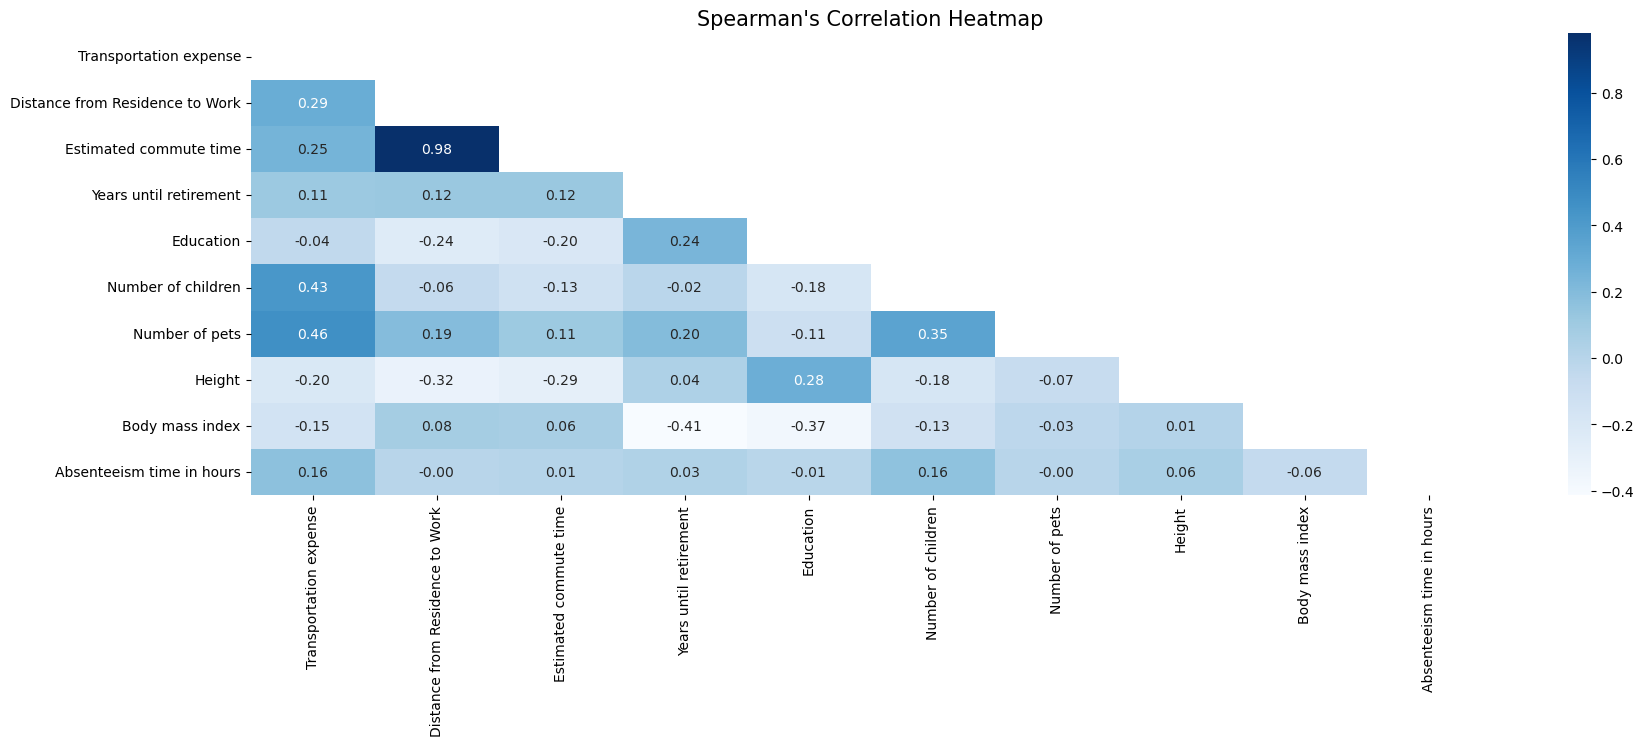

In [56]:
abs_numeric = abs.select_dtypes(include="number")
corr_matrix = abs_numeric.corr(method="spearman")
corr_heatmap(corr_matrix)

A very strong positive correlation was found between Estimated Commute Time and Distance from Residence to Work. This indicates the presence of multicollinearity, meaning both variables carry almost the same information. To avoid redundancy and improve model interpretability, Estimated Commute Time will be removed because its a variable that depends on external factors, while Distance to Work is fixed.

In [57]:
abs = abs.drop(columns = ['Estimated commute time'])
abs

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Date of Birth,Disciplinary failure,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Body mass index,Absenteeism time in hours
ID,,,,,,,,,,,,,,,,,,,
11,Unjustified absence,July,Tuesday,Summer,289,36,13,32,1992-08-15,No,1,2,Y,No,1,90,172,30,4
36,Unspecified,July,Tuesday,NaN,118,13,18,15,1975-09-02,Yes,1,1,Y,No,0,98,178,31,0
3,Medical consultation,July,Wednesday,Summer,179,51,18,27,1987-04-08,No,1,0,Yes,No,0,89,170,31,2
7,Diseases of the eye and adnexa,July,Thursday,NaN,279,5,14,26,1986-07-25,No,1,2,Yes,Yes,0,68,168,24,4
11,Medical consultation,July,Thursday,Summer,289,36,13,32,1992-08-15,No,1,2,Yes,No,1,90,172,30,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,Diseases of the genitourinary system,July,Tuesday,Summer,289,36,13,32,1992-08-15,No,1,2,Yes,No,1,90,172,30,8
1,Diseases of the digestive system,July,Tuesday,Summer,235,11,14,28,1988-06-01,No,3,1,No,No,1,88,172,29,4
4,Unspecified,NaN,Tuesday,Summer,118,14,13,25,1985-10-20,No,1,1,Yes,No,8,98,170,34,0


<a id="distributions"></a>

### **Distributions <font>**

In [58]:
plot_hist_and_box(abs)

In [59]:
plot_categorical_barcharts(abs)

 - Education needs to be converted to categorical variable, but most pepople have the lowest level of education;
 - Transportation Expense: right-skewed with outliers (some workers have much higher commuting costs).
 - Distance to Work: bimodal, potentially two main employee clusters (close vs. far).
 - Years until retirment: most employees are young or mid-career, with around 25–35 years until retirement, while a few outliers nearing retirement indicate an overall younger workforce.
 - Height presents some significant outliers

Some initial conclusions:

For Numeric:

    - Education needs to be converted to categorical variable, but most pepople have the lowest level of education;
    - Transportation Expense: right-skewed with outliers (some workers have much higher commuting costs).
    - Distance to Work: bimodal, potentially two main employee clusters (close vs. far).
    - Years until retirment: most employees are young or mid-career, with around 25–35 years until retirement, while a few outliers nearing retirement indicate an overall younger workforce.
    - Height presents some significant outliers

For Categorical:

    - Medical and Dental consultations are the most common reason for absence among employees;
    - Most employees are absent in march and february (end of summer - beginning of autumn -> days of for vacation);
    - They tend to be absent mostly on mondays and least on saturdays (in brasil they work 4h on saturdays);
    - Spring is the season of most absences, followed by autumn;
    - Mostly newer employees;
    - Majority are social drinkers and non-smokers, whose absences did not violate company's policy.

<a id="multivariate-analysis"></a>

### **Multivariate Analysis <font>**

Check for multivariate outliers and inconsitencies:

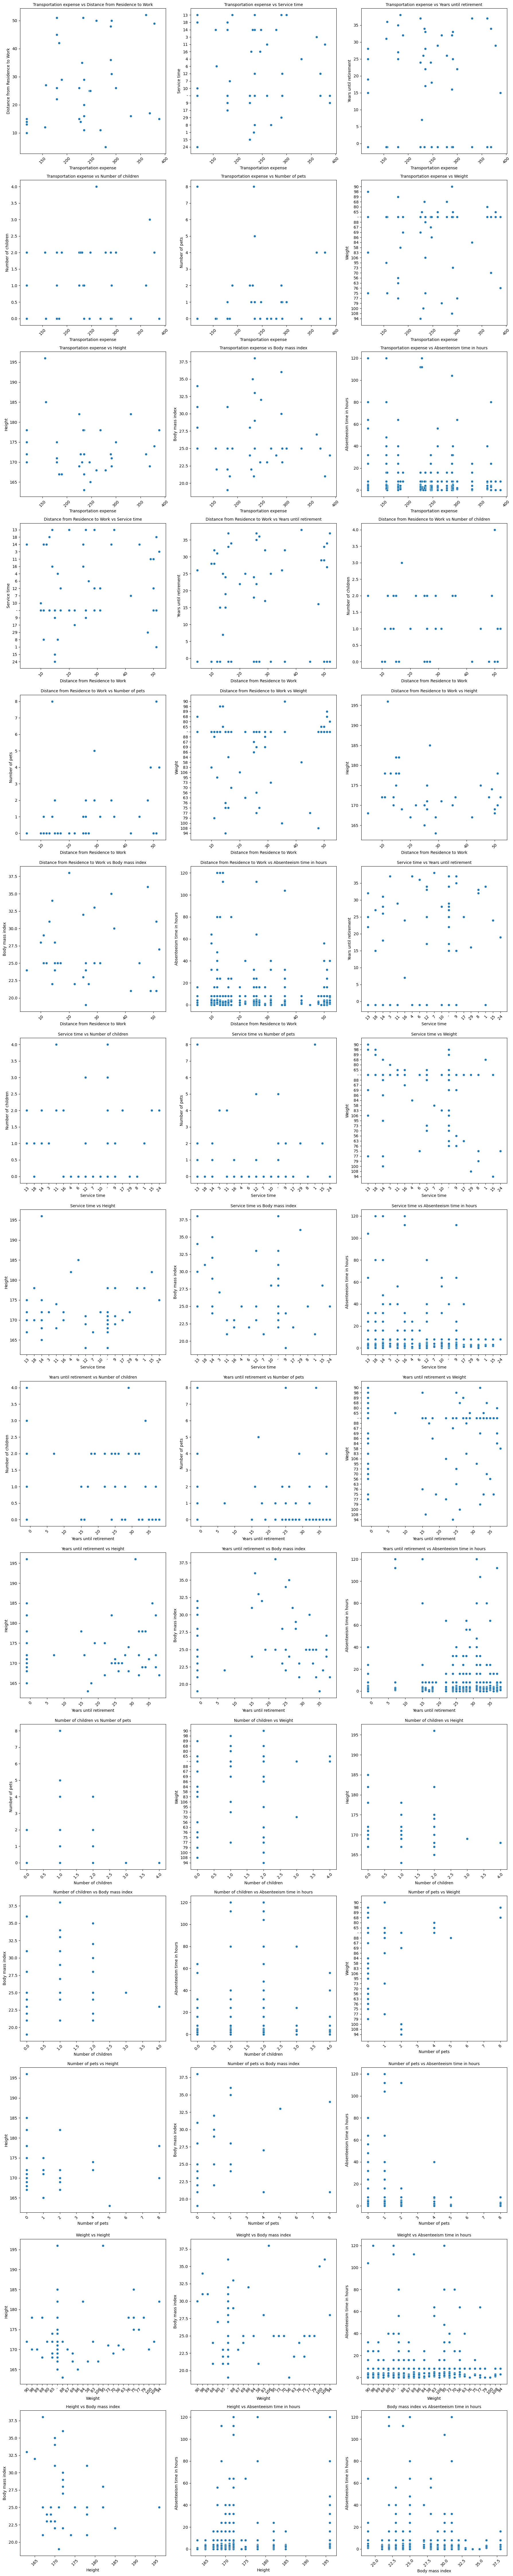

In [60]:
abs_plot = abs.reset_index(drop=True)

variables = [
    'Transportation expense', 'Distance from Residence to Work', 
    'Service time', 'Years until retirement', 
    'Number of children', 'Number of pets', 'Weight', 
    'Height', 'Body mass index', 'Absenteeism time in hours'
]

COLUMNS_PER_ROW = 3

# 1. Determine all unique pairs
plot_pairs = []
for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        if j > i: 
            plot_pairs.append((var1, var2))

num_plots = len(plot_pairs)
num_rows = (num_plots + COLUMNS_PER_ROW - 1) // COLUMNS_PER_ROW 

# 2. Create the Figure and Axes grid
fig, axes = plt.subplots(
    nrows=num_rows, 
    ncols=COLUMNS_PER_ROW, 
    figsize=(6 * COLUMNS_PER_ROW, 6 * num_rows) # Adjust figure size for readability
)
# Flatten the axes array for easy indexing, and ensure it's a list even if only one row
axes = axes.flatten() if num_rows > 1 or COLUMNS_PER_ROW > 1 else [axes]

# 3. Iterate through the pairs and plot them on the grid
for k, (var1, var2) in enumerate(plot_pairs):
    ax = axes[k]
    
    # Generate the scatter plot 
    sns.scatterplot(x=var1, y=var2, data=abs_plot, ax=ax)
    
    # Set titles
    ax.set_title(f'{var1} vs {var2}', fontsize=10)
    ax.tick_params(axis='x', rotation=45) 
    
# 4. Hide any unused subplots
for k in range(num_plots, len(axes)):
    fig.delaxes(axes[k])

# 5. Optimize layout and display
plt.tight_layout()
plt.show()


- Most variable pairs show no strong linear relationship, indicating many features are independent or require nonlinear analysis.

<a id="duplicates"></a>

### **Duplicates <font>**

In [80]:
duplicates = abs[abs.duplicated(keep=False)]
display(duplicates.head())

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Date of Birth,Disciplinary failure,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Body mass index,Absenteeism time in hours
ID,,,,,,,,,,,,,,,,,,,
10,Patient follow-up,July,Friday,Summer,361,52,3,37,1997-07-08,No,1,1,Yes,No,4,80,172,27,8
20,NaN,NaN,NaN,NaN,260,50,11,29,1989-02-20,No,1,4,Yes,No,0,65,168,23,8
20,NaN,NaN,NaN,NaN,260,50,11,29,1989-02-20,No,1,4,Yes,No,0,65,168,23,8
3,NaN,NaN,NaN,NaN,179,51,18,27,1987-04-08,No,1,0,Y,No,0,89,170,31,3
34,Medical consultation,October,Tuesday,Spring,118,10,10,28,1988-05-10,No,1,0,No,No,0,83,172,28,3


In [62]:
len(duplicates)

52

There are 52 duplicates, which can mean two different things:
 - People are absent twice or more in the same day
 - These are true duplicates

Upon observation, the rows identified as duplicates can legitimatly represent abscenses reported for the same worker in different days of a given month.

This happens due to the present granularity, the bottom of the date hierarchy ends in "month", so there is no way to identify if 2 given abscences (rows) take place in different days.

Considering this, duplicate rows will be kept.

<a id="data-pre-processing"></a>

# **Data Pre-processing<font>**

<a id="inicial-data-pre-processing"></a>

### **Initial Data Pre-processing<font>**



In this step, the preprocessing pipeline is applied to the raw dataset in order to standardize and clean the data while preserving the original missing-value structure.

The pipeline performs the following operations:
- Standardizes binary variables (e.g., *Yes/No*, *Y/N*) into numerical format (0/1)
- Attempts to automatically convert object-type columns into numeric or datetime formats where applicable
- Replaces special missing-value markers (e.g., `-1`, `'-'`) with proper `NaN` values

Missing-value imputation is **intentionally disabled** at this stage (`impute_missing=False`) to allow for exploratory analysis and validation of missingness patterns before applying any imputation strategy.


In [63]:
modded_abs = abs.copy()

In [64]:
modded_abs = pp_pipeline(modded_abs, impute_missing=False)

Step 1: Standardized binary columns: ['Disciplinary failure', 'Social drinker', 'Social smoker']
Step 2.1: Changed to following columns to integer type : []
Step 2.2: Changed to following columns to datetime type : ['Date of Birth']
Columns containing '-' values:


Weight          77
Service time    28
dtype: int64


Total rows containing '-': 104


,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Date of Birth,Disciplinary failure,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Body mass index,Absenteeism time in hours
ID,,,,,,,,,,,,,,,,,,,
14,"Injury, poisoning and other consequences of ex...",July,Monday,Summer,155,12,14,31.0,1991-09-10,0,1,2,1,0,0,-,196,25,40
3,Factors influencing health status and contact ...,July,Monday,Summer,179,51,18,27.0,1987-04-08,0,1,0,1,0,0,-,170,31,8
30,Dental consultation,August,Wednesday,Summer,157,27,6,36.0,1996-05-22,0,1,0,1,1,0,-,185,22,4
5,"Injury, poisoning and other consequences of ex...",September,Tuesday,NaN,235,20,-,22.0,1982-06-19,0,1,1,1,0,0,106,167,38,8
34,Medical consultation,September,Monday,Summer,118,10,10,28.0,1988-05-10,0,1,0,0,0,0,-,172,28,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,"Injury, poisoning and other consequences of ex...",April,Tuesday,Winter,361,52,3,37.0,1997-07-08,0,1,1,1,0,4,-,172,27,8
28,"Injury, poisoning and other consequences of ex...",April,Monday,NaN,225,26,-,37.0,1997-08-03,0,1,1,0,0,2,-,169,24,8
28,Diseases of the nervous system,May,Wednesday,Winter,225,26,-,37.0,1997-08-03,0,1,1,0,0,2,69,169,24,3


Step 3.1: Replaced 45 occurrences of -1 with NaN.
Step 3.1: Replaced 105 occurrences of '-' with NaN.


### **Feature Transformation and Engineering<font>**
Applying dataset specific transformations to facilitate analysis and future clustering

#### Transforming Date of Birth into Age

In [65]:
Age = (datetime.today().year - pd.to_datetime(modded_abs['Date of Birth']).dt.year)

modded_abs.insert(loc=1, column='Age', value=Age)

In [66]:
modded_abs = modded_abs.drop(columns=['Date of Birth'])

#### Mapping education to numeric scale

In [67]:

education_mapping = {
    1: 'High School',
    2: 'Graduate',
    3: 'Postgraduate',
    4: 'Master’s or PhD',
    np.nan : np.nan
}

modded_abs['Education'] = modded_abs['Education'].map(education_mapping)

### <a id="Imputing-missing-values"></a>

### **Imputing missing values<font>**

Now that all values are standardize to fit the purpose of this project, we are able to imput the previously found missing values.

In [68]:
modded_abs = pp_pipeline(modded_abs,  standardize_binary=False,
    change_datatypes = False,
    replace_special_missing = False,
    impute_missing = True)

Step 3.2: Imputed missing values. Total missing values before: 560, after: 0.


<a id="worker-groups-analysis"></a>

## **Worker Groups Analysis<font>**

<a id="worker-first-table"></a>

### **Worker-first table<font>**

Create a worker based dataframe where:

- rows are grouped by worker ID
- Abseentism related data is summed
- Demographic variables are, in case of discrepancies, described by the most common value
- highest number of consecutive dates is presented

In [69]:
processed_abs = modded_abs.copy()

In [70]:
 #define demographic columns and absence related columns
demographic_cols =[
        'Transportation expense', 'Distance from Residence to Work',
        'Service time', 'Years until retirement',
          'Education',
        'Number of children', 'Social drinker', 'Social smoker',
        'Number of pets', 'Weight', 'Height', 'Body mass index']

absence_time_col = 'Absenteeism time in hours'

Using one hot enconding on the Reasons for abscence so it's possible to quantify the amount of abscences by reason provided.

In [71]:
OHE_abs = pd.concat([processed_abs, pd.get_dummies(processed_abs["Reason for absence"], prefix="Reason", drop_first=True).astype(int)], axis=1)

In [72]:
grouped_workers =group_by_worker(processed_abs, demographic_cols, absence_time_col=absence_time_col)

#remapping Social drinker and Social smoker to 0 and 1
grouped_workers['Social drinker'] = grouped_workers['Social drinker'].map({'No': 0, 'Yes': 1})
grouped_workers['Social smoker'] = grouped_workers['Social smoker'].map({'No': 0, 'Yes': 1})

In [73]:
grouped_workers.head(10)

,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Body mass index,Absenteeism time in hours_count,Absenteeism time in hours_sum,Absenteeism time in hours_mean
ID,,,,,,,,,,,,,,,
1,235,11,14.0,28.0,Postgraduate,1,NaN,NaN,1,88.0,172,29,24,122,5.083333
2,235,29,12.0,17.0,High School,1,NaN,NaN,5,88.0,163,33,6,25,4.166667
3,179,51,18.0,27.0,High School,0,NaN,NaN,0,89.0,170,31,122,501,4.106557
4,118,14,13.0,25.0,High School,1,NaN,NaN,8,98.0,170,34,1,0,0.000000
5,235,20,13.0,22.0,High School,1,NaN,NaN,0,106.0,167,38,20,112,5.600000
6,189,29,13.0,32.0,High School,2,NaN,NaN,2,69.0,167,25,8,72,9.000000
7,279,5,14.0,26.0,High School,2,NaN,NaN,0,68.0,168,24,6,30,5.000000
8,231,35,14.0,26.0,High School,2,NaN,NaN,2,100.0,170,35,2,0,0.000000
9,228,14,16.0,7.0,High School,2,NaN,NaN,1,65.0,172,22,10,377,37.700000


<a id="abscence-first-table"></a>

### **Abscence-first table<font>**


Construct and select variables to be used for clustering.

<a id="encoding-variables"></a>

#### **Encoding Variables<font>**

##### Encoding body mass index into custom classes

In [74]:
#Map BMI values to categories
bmi_map = {
    (-np.inf, 18.5): 'Underweight',
    (18.5, 25.0): 'Healthy Weight',
    (25.0, 30.0): 'Overweight',
    (30.0, 35.0): 'Obesity Class I',
    (35.0, 40.0): 'Obesity Class II',
    (40.0, np.inf): 'Obesity Class III'
}

intervals = list(bmi_map.keys())
bins = [iv[0] for iv in intervals] + [intervals[-1][1]]
labels = list(bmi_map.values())

#Map variable to above categories
processed_abs['bmi_category'] = pd.cut(
    processed_abs['Body mass index'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
).astype('object')

#drop original BMI column
processed_abs = processed_abs.drop(columns=['Body mass index'])

##### Encoding using One-hot encoding

In [75]:
# Encoding other categorical values to still-categorical dummies
cat_cols = ['Day of the week', 'Seasons','Education','bmi_category']
# create dummy variables for *only* these columns
processed_abs = pd.get_dummies(processed_abs, columns=cat_cols, drop_first=True)


##### Encoding Month using cyclical encoding

In [76]:
# Convert month names to numbers (1–12)
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}

processed_abs['Month_num'] = processed_abs['Month of absence'].map(month_map)

# Cyclical encoding
processed_abs['Month_sin'] = np.sin(2 * np.pi * processed_abs['Month_num'] / 12)
processed_abs['Month_cos'] = np.cos(2 * np.pi * processed_abs['Month_num'] / 12)

# Drop Month_num
processed_abs = processed_abs.drop(columns=['Month_num'])

# Then drop the original column
processed_abs = processed_abs.drop(columns=['Month of absence'])

##### Encoding Reason for abscence using frequency encoding

In [77]:
freq_map = processed_abs['Reason for absence'].value_counts(normalize=True)
processed_abs['Reason_for_abs_freq'] = processed_abs['Reason for absence'].map(freq_map)

# Then drop the original column
processed_abs = processed_abs.drop(columns=['Reason for absence'])

<a id="dataset-extraction"></a>

 # **Dataset Extraction<font>**

In [ ]:
base_path = Path.cwd()
# Go one folder back and then into 'data'
data_path = base_path.parent / "data"


# Save the CSV
processed_abs.to_csv(
    data_path / "Processed Absenteeism Dataset.csv",
    index=False
)
grouped_workers.to_csv(
    data_path / "Grouped Workers Absenteeism Dataset.csv",
    index=False
)